Langgraph - 节点与可控制性
****
第一个Langgraph；
基本控制：串行控制；
基本控制：分支控制；
基本控制：条件与循环；
精细控制：图的运行时配置；
精细控制：map_reduce

第一个langgraph
****
安装环境- pip install -U langgraph

定义state(节点与节点通信的数据流)
****
TypedDict:属于Python标准库typing模块的一部分，仅提供静态类型检查，运行时不执行验证
Pydantic:第三方库、需要单独安装、提供运行时数据验证和序列化功能

In [2]:
from langchain_core.messages import AnyMessage
from pyexpat import model
from typing_extensions import TypedDict

#定义节点间通讯的消息格式
class State(TypedDict):
    messages:list[AnyMessage]
    extra_field:int

定义节点
****

In [3]:
from langchain_core.messages import AIMessage

def node(state:State):
    messages=state["messages"]
    new_message=AIMessage("你好，我是节点1")

    return {"messages":messages+[new_message],"extra_field":1}

创建图
***
包含一个节点
使用state通信

In [4]:
from langgraph.graph import StateGraph

graph = StateGraph(State)
graph.add_node(node)
graph.set_entry_point("node")
graph_builder = graph.compile()

查看节点与图结构
****
Mermaid是一种基于文本的图表和可视化工具，它允许用户通过简单的文本语法来创建复杂的图表和流程图。它特别适合开发者、文档编写库或网页中嵌入可视化内容。

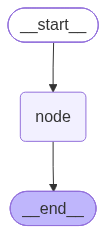

In [5]:
from IPython.display import Image,display

display(Image(graph_builder.get_graph().draw_mermaid_png()))

调用

In [6]:
from langchain_core.messages import HumanMessage

result = graph_builder.invoke({
    "messages":[HumanMessage("你好啊，我是红狼！")]
})
result

{'messages': [HumanMessage(content='你好啊，我是红狼！', additional_kwargs={}, response_metadata={}),
  AIMessage(content='你好，我是节点1', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])],
 'extra_field': 1}

使用pretty_print来格式化显示
***

In [7]:
from langchain_core.messages import HumanMessage

result = graph_builder.invoke({
    "messages":[HumanMessage("你好啊，我是红狼！")]
})
for messages in result["messages"]:
    messages.pretty_print()

================================ Human Message =================================

你好啊，我是红狼！
================================== Ai Message ==================================

你好，我是节点1


串行控制
****

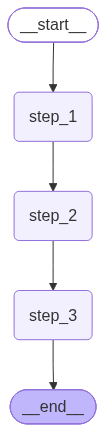

In [8]:
from typing_extensions import TypedDict
from IPython.display import Image,display
from langgraph.graph import START,StateGraph,END

class State(TypedDict):
    value_1:str
    value_2:str

def step_1(state:State):
    return {"value_1":state["value_1"]}

def step_2(state:State):
    current_value_1 = state["value_1"]
    return {"value_1":f"{current_value_1}+b"}

def step_3(state:State):
    return {"value_2":10}

graph_builder = StateGraph(State)
graph_builder.add_node(step_1)
graph_builder.add_node(step_2)
graph_builder.add_node(step_3)

graph_builder.add_edge(START,"step_1")
graph_builder.add_edge("step_1","step_2")
graph_builder.add_edge("step_2","step_3")
graph_builder.add_edge("step_3",END)

graph = graph_builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [9]:
graph.invoke({"value_1": "c","value_2":9})

{'value_1': 'c+b', 'value_2': 10}

分支控制
****

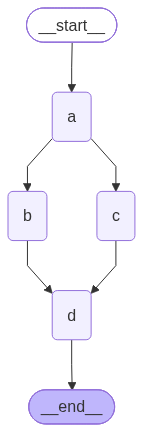

In [10]:
import operator
from typing import Any,Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from IPython.display import Image,display

#Annotated允许为类型提供额外的元数据，而不影响类型检查起对类型本身的理解
class State(TypedDict):
    aggregate:Annotated[list,operator.add]

def a(state:State):
    print(f"添加“A”到{state['aggregate']}")
    return {"aggregate":["A"]}

def b(state:State):
    print(f"添加“B”到{state['aggregate']}")
    return {"aggregate":["B"]}

def c(state:State):
    print(f"添加“C”到{state['aggregate']}")
    return {"aggregate":["C"]}

def d(state:State):
    print(f"添加“D”到{state['aggregate']}")
    return {"aggregate":["D"]}

builder = StateGraph(State)
builder.add_node(a)
builder.add_node(b)
builder.add_node(c)
builder.add_node(d)

builder.add_edge(START,"a")
builder.add_edge("a","b")
builder.add_edge("a","c")
builder.add_edge("b","d")
builder.add_edge("c","d")
builder.add_edge("d",END)
graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [11]:
graph.invoke({"aggregate":[]},{"configurable":{"thread":"foo"}})

添加“A”到[]
添加“B”到['A']
添加“C”到['A']
添加“D”到['A', 'B', 'C']


{'aggregate': ['A', 'B', 'C', 'D']}

条件分支和循环
****

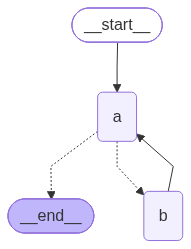

In [12]:
import operator
from typing_extensions import TypedDict
from typing import Annotated,Literal
from langgraph.graph import StateGraph,START,END

class State(TypedDict):
    aggregate:Annotated[list,operator.add]

def a(state:State):
    print(f"Node A sees {state['aggregate']}")
    return {"aggregate":["A"]}

def b(state:State):
    print(f"Node B sees {state['aggregate']}")
    return {"aggregate":["B"]}

#Define nodes
builder = StateGraph(State)
builder.add_node(a)
builder.add_node(b)

#Define edges
def route(state:State) -> Literal["b",END]:
    if len(state["aggregate"]) < 7:
        return "b"
    else:
        return END

builder.add_edge(START,"a")
builder.add_conditional_edges("a",route)
builder.add_edge("b","a")
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [13]:
graph.invoke({"aggregate":[]})

Node A sees []
Node B sees ['A']
Node A sees ['A', 'B']
Node B sees ['A', 'B', 'A']
Node A sees ['A', 'B', 'A', 'B']
Node B sees ['A', 'B', 'A', 'B', 'A']
Node A sees ['A', 'B', 'A', 'B', 'A', 'B']


{'aggregate': ['A', 'B', 'A', 'B', 'A', 'B', 'A']}

使用递归限制recursion_limit来防止异常情况的大量无用调用

In [14]:
from langgraph.errors import GraphRecursionError

try:
    graph.invoke({"aggregate":[]},{"recursion_limit":4})
except GraphRecursionError:
    print("Recursion Error")

Node A sees []
Node B sees ['A']
Node A sees ['A', 'B']
Node B sees ['A', 'B', 'A']
Recursion Error


循环

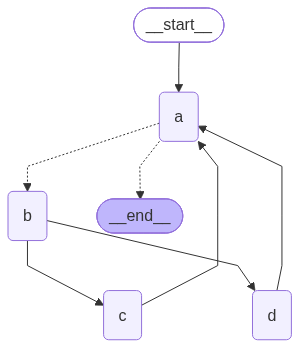

In [15]:
import operator
from typing import Any,Annotated,Literal
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from IPython.display import Image,display

#Annotated允许为类型提供额外的元数据，而不影响类型检查起对类型本身的理解
class State(TypedDict):
    aggregate:Annotated[list,operator.add]

def a(state:State):
    print(f"Node A sees {state['aggregate']}")
    return {"aggregate":["A"]}

def b(state:State):
    print(f"Node B sees {state['aggregate']}")
    return {"aggregate":["B"]}

def c(state:State):
    print(f"Node C sees {state['aggregate']}")
    return {"aggregate":["C"]}

def d(state:State):
    print(f"Node D sees {state['aggregate']}")
    return {"aggregate":["D"]}

#节点
builder = StateGraph(State)
builder.add_node(a)
builder.add_node(b)
builder.add_node(c)
builder.add_node(d)

#边
def route(state:State) -> Literal["b",END]:
    if len(state["aggregate"])<7:
        return "b"
    else:
        return END

builder.add_edge(START,"a")
builder.add_conditional_edges("a",route)
builder.add_edge("b","c")
builder.add_edge("b","d")
builder.add_edge(["c","d"],"a")
graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [16]:
result = graph.invoke({"aggregate": []})


Node A sees []
Node B sees ['A']
Node C sees ['A', 'B']
Node D sees ['A', 'B']
Node A sees ['A', 'B', 'C', 'D']
Node B sees ['A', 'B', 'C', 'D', 'A']
Node C sees ['A', 'B', 'C', 'D', 'A', 'B']
Node D sees ['A', 'B', 'C', 'D', 'A', 'B']
Node A sees ['A', 'B', 'C', 'D', 'A', 'B', 'C', 'D']


图的运行时配置
****

In [ ]:
import operator
from typing import Annotated,Sequence
from typing_extensions import TypedDict
from langchain_deepseek import ChatDeepSeek
from langchain_openai import ChatOpenAI
import os
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.runnables.config import RunnableConfig
from langgraph.graph import END, StateGraph, START

model = ChatDeepSeek(
    model="pro/deepseek-ai/DeepSeek-V3",
    temperature=0,
    api_key=os.environ.get("DEEPSEEK_AP_KEY"),
    base_url=os.environ.get("DEEPSEEK_AP_BASE"),
)